<a href="https://colab.research.google.com/github/Renad-Wael/ITI_Task/blob/main/0_1_CNN_callbacks_Cifar_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


In [3]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


In [4]:
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (60000, 10)
y_test shape: (10000, 10)


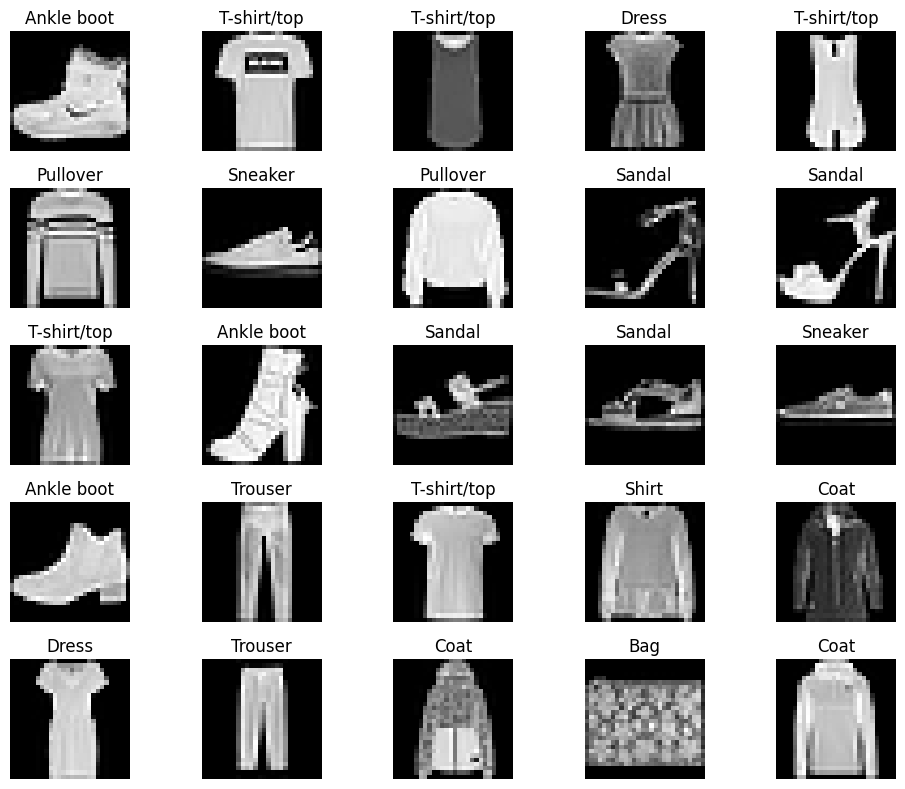

In [5]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

plt.figure(figsize=(10, 8))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
model = models.Sequential([

    layers.Input(shape=(28, 28, 1)),

    # First convolutional block
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2, 2)),

    layers.Dropout(0.25),

    # Second convolutional block
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2, 2)),

    layers.Dropout(0.25),

    # Third convolutional block
    layers.Conv2D(
        128,
        (3, 3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2, 2)),

    layers.Dropout(0.25),

    # Fully connected layers
    layers.Flatten(),

    layers.Dense(
        256,
        activation='relu'
    ),

    layers.Dropout(0.5),

    layers.Dense(
        10,
        activation='softmax'
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,306 (1.49 MB)

 Trainable params: 390,858 (1.49 MB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'cnn_fashion_mnist.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [9]:
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=30,
    shuffle=True,
    validation_data=(x_test, y_test),
    callbacks=[
        reduce_lr,
        early_stop,
        checkpoint
    ]
)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4701 - loss: 1.8454
Epoch 1: val_accuracy improved from None to 0.61560, saving model to cnn_fashion_mnist.h5



Epoch 1: finished saving model to cnn_fashion_mnist.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.6008 - loss: 1.2047 - val_accuracy: 0.6156 - val_loss: 1.1342 - learning_rate: 1.0000e-04
Epoch 2/30
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7333 - loss: 0.7234
Epoch 2: val_accuracy improved from 0.61560 to 0.79990, saving model to cnn_fashion_mnist.h5



Epoch 2: finished saving model to cnn_fashion_mnist.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7432 - loss: 0.7004 - val_accuracy: 0.7999 - val_loss: 0.5401 - learning_rate: 1.0000e-04
Epoch 3/30
461/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7714 - loss: 0.6188
Epoch 3: val_accuracy improved from 0.79990 to 0.82650, saving model to cnn_fashion_mnist.h5



Epoch 3: finished saving model to cnn_fashion_mnist.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7787 - loss: 0.5977 - val_accuracy: 0.8265 - val_loss: 0.4708 - learning_rate: 1.0000e-04
Epoch 4/30
462/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8025 - loss: 0.5425
Epoch 4: val_accuracy improved from 0.82650 to 0.83870, saving model to cnn_fashion_mnist.h5



Epoch 4: finished saving model to cnn_fashion_mnist.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8071 - loss: 0.5303 - val_accuracy: 0.8387 - val_loss: 0.4410 - learning_rate: 1.0000e-04
Epoch 5/30
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8161 - loss: 0.5032
Epoch 5: val_accuracy improved from 0.83870 to 0.85140, saving model to cnn_fashion_mnist.h5


...


Epoch 17: finished saving model to cnn_fashion_mnist.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8891 - loss: 0.3014 - val_accuracy: 0.9037 - val_loss: 0.2674 - learning_rate: 1.0000e-04
Epoch 18/30
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8929 - loss: 0.2918
Epoch 18: val_accuracy did not improve from 0.90370
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8918 - loss: 0.2929 - val_accuracy: 0.9024 - val_loss: 0.2650 - learning_rate: 1.0000e-04
Epoch 19/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8928 - loss: 0.2862
Epoch 19: val_accuracy did not improve from 0.90370
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8937 - loss: 0.2884 - val_accuracy: 0.8977 - val_loss: 0.2783 - learning_rate: 1.0000e-04
Epoch 20/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8969 - loss: 0.2835
Epoch 20: val_accuracy improved from 0.90370 to 0.91050, saving model to cnn_fashion_mnist.h5



Epoch 20: finished saving model to cnn_fashion_mnist.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8971 - loss: 0.2818 - val_accuracy: 0.9105 - val_loss: 0.2510 - learning_rate: 1.0000e-04
Epoch 21/30
461/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8995 - loss: 0.2741
Epoch 21: val_accuracy did not improve from 0.91050
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8974 - loss: 0.2783 - val_accuracy: 0.9059 - val_loss: 0.2543 - learning_rate: 1.0000e-04
Epoch 22/30
463/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8983 - loss: 0.2722
Epoch 22: val_accuracy did not improve from 0.91050
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8997 - loss: 0.2712 - val_accuracy: 0.9092 - val_loss: 0.2478 - learning_rate: 1.0000e-04
Epoch 23/30
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9023 - loss: 0.2659
Epoch 23: val_accuracy improved from 0.91050 to 0.91110, saving model to cnn_fashion_mnist.h5



Epoch 23: finished saving model to cnn_fashion_mnist.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9020 - loss: 0.2655 - val_accuracy: 0.9111 - val_loss: 0.2445 - learning_rate: 1.0000e-04
Epoch 24/30
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9025 - loss: 0.2629
Epoch 24: val_accuracy did not improve from 0.91110
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9036 - loss: 0.2615 - val_accuracy: 0.9098 - val_loss: 0.2485 - learning_rate: 1.0000e-04
Epoch 25/30
464/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9033 - loss: 0.2636
Epoch 25: val_accuracy improved from 0.91110 to 0.91340, saving model to cnn_fashion_mnist.h5



Epoch 25: finished saving model to cnn_fashion_mnist.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9039 - loss: 0.2597 - val_accuracy: 0.9134 - val_loss: 0.2393 - learning_rate: 1.0000e-04
Epoch 26/30
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9059 - loss: 0.2527
Epoch 26: val_accuracy did not improve from 0.91340
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9074 - loss: 0.2516 - val_accuracy: 0.9132 - val_loss: 0.2422 - learning_rate: 1.0000e-04
Epoch 27/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9089 - loss: 0.2493
Epoch 27: val_accuracy did not improve from 0.91340
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9089 - loss: 0.2479 - val_accuracy: 0.9121 - val_loss: 0.2383 - learning_rate: 1.0000e-04
Epoch 28/30
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9076 - loss: 0.2476
Epoch 28: val_accuracy improved from 0.91340 to 0.91530, saving model to cnn_fashion_mnist.h5



Epoch 28: finished saving model to cnn_fashion_mnist.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9093 - loss: 0.2469 - val_accuracy: 0.9153 - val_loss: 0.2390 - learning_rate: 1.0000e-04
Epoch 29/30
464/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9138 - loss: 0.2340
Epoch 29: val_accuracy did not improve from 0.91530
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9115 - loss: 0.2400 - val_accuracy: 0.9137 - val_loss: 0.2403 - learning_rate: 1.0000e-04
Epoch 30/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9104 - loss: 0.2388
Epoch 30: val_accuracy did not improve from 0.91530
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9100 - loss: 0.2399 - val_accuracy: 0.9143 - val_loss: 0.2338 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 30.


In [10]:
model = tf.keras.models.load_model(
    'cnn_fashion_mnist.h5'
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

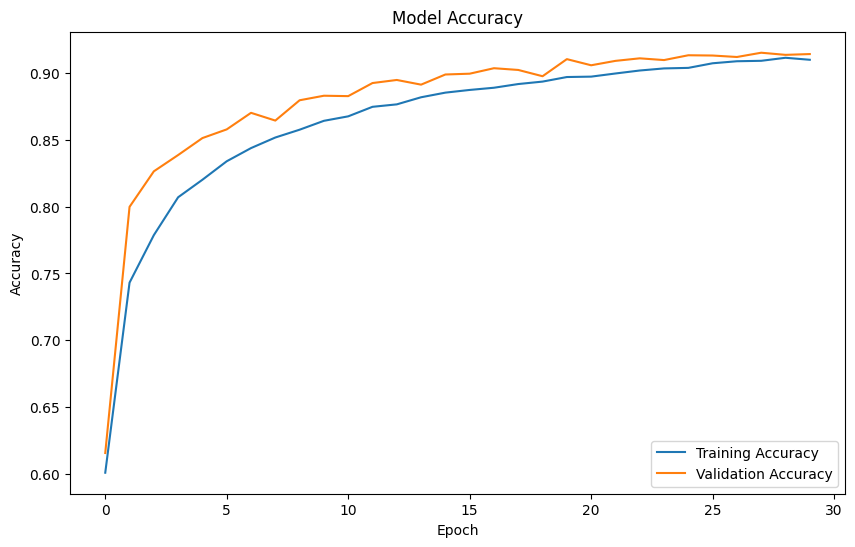

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()

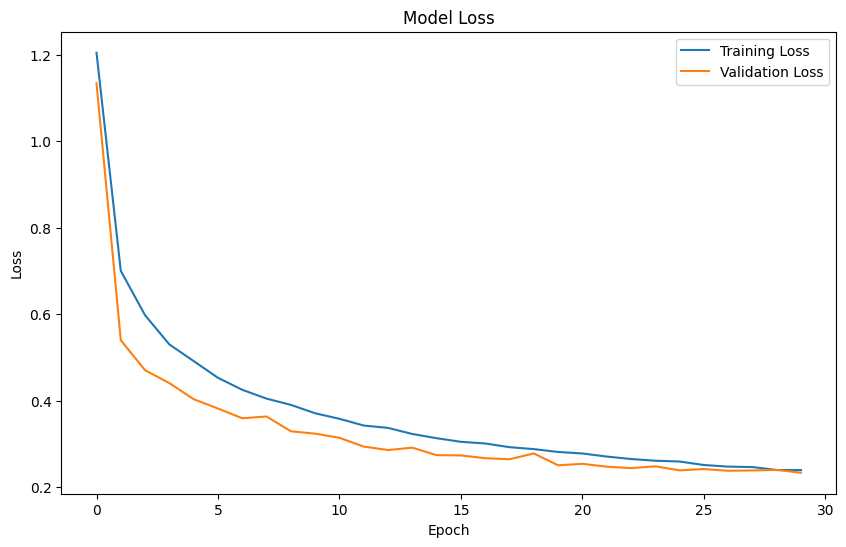

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.show()

In [13]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=2
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 - 2s - 7ms/step - accuracy: 0.9153 - loss: 0.2390
Test Loss: 0.23904557526111603
Test Accuracy: 0.9153000116348267


In [14]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score
)

# Predictions
y_prob = model.predict(x_test, verbose=0)

y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
print(
    classification_report(
        y_true,
        y_pred,
        labels=np.arange(10),
        target_names=class_names
    )
)

# Confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

# Balanced accuracy
balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

print("Balanced Accuracy:", balanced_acc)

              precision    recall  f1-score   support

 T-shirt/top       0.91      0.83      0.87      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.90      0.87      0.88      1000
       Dress       0.92      0.92      0.92      1000
        Coat       0.84      0.87      0.85      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.72      0.80      0.76      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.99      0.98      0.98      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

Confusion Matrix:
[[830   0  15  19   7   1 122   0   6   0]
 [  0 977   0  13   5   0   3   0   2   0]
 [  9   1 868   9  55   0  57   0   1   0]
 [  7   3   8 920  29   0  33   0   0   0]
 [  0   0  27  17 870   0  86   0   0   0]
 [  0   

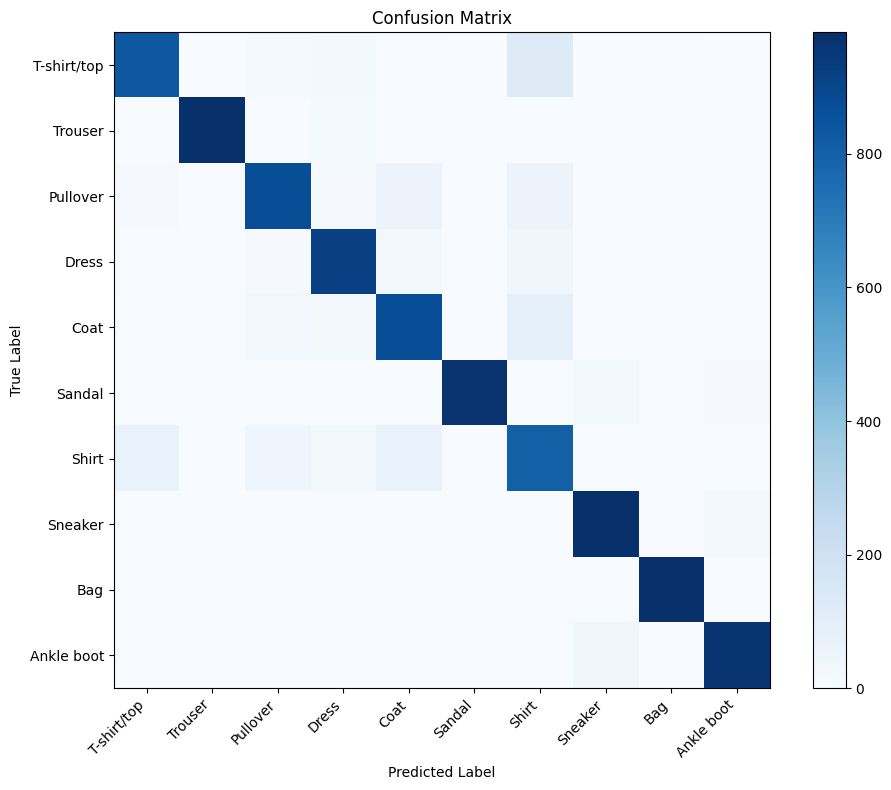

In [15]:
plt.figure(figsize=(10, 8))

plt.imshow(cm, cmap='Blues')

plt.title('Confusion Matrix')
plt.colorbar()

plt.xticks(
    np.arange(10),
    class_names,
    rotation=45,
    ha='right'
)

plt.yticks(
    np.arange(10),
    class_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

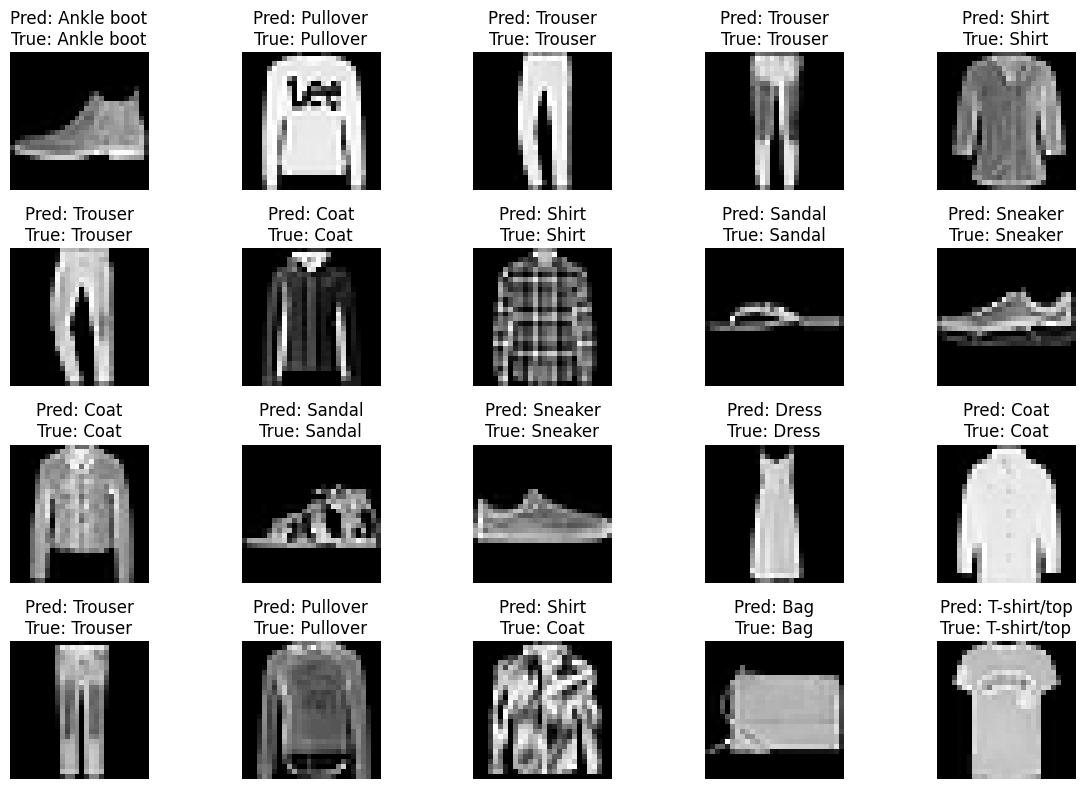

In [16]:
plt.figure(figsize=(12, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    plt.imshow(
        x_test[i].squeeze(),
        cmap='gray'
    )

    predicted = y_pred[i]
    actual = y_true[i]

    plt.title(
        f"Pred: {class_names[predicted]}\n"
        f"True: {class_names[actual]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [20]:
# Get filters from the first convolutional layer

first_conv_layer = None

for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        first_conv_layer = layer
        break

filters, biases = first_conv_layer.get_weights()

print("Filter shape:", filters.shape)
print("Number of filters:", filters.shape[-1])

Filter shape: (3, 3, 1, 32)
Number of filters: 32


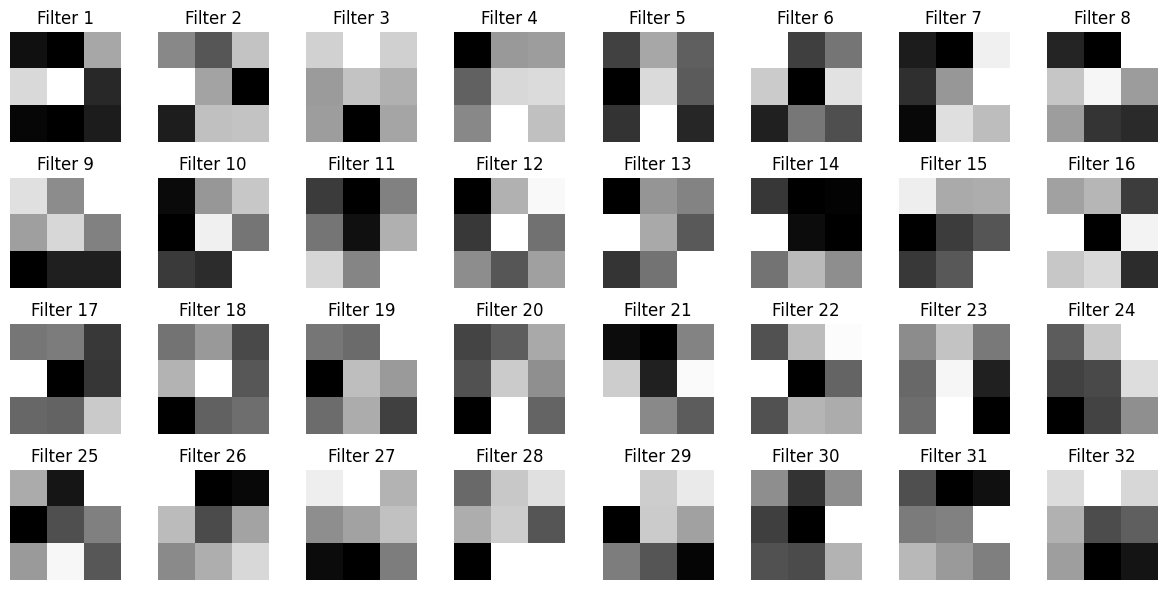

In [21]:
fig, axes = plt.subplots(
    4,
    8,
    figsize=(12, 6)
)

for i, ax in enumerate(axes.flat):

    filter_img = filters[:, :, 0, i]

    ax.imshow(
        filter_img,
        cmap='gray'
    )

    ax.set_title(f'Filter {i + 1}')
    ax.axis('off')

plt.tight_layout()
plt.show()